# 08. Electricity prices across Europe
Price ranking and negative hours with SQL, solar capture rate and battery value by country, and a summary table for 2025.

In [17]:
# Import the libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Read the European data and convert the time to Central European time, the time of the market
prices = pd.read_csv("../data/europe_prices.csv", index_col="time_utc")
production = pd.read_csv("../data/europe_production.csv", index_col="time_utc")
prices.index = pd.to_datetime(prices.index, utc=True).tz_convert("Europe/Brussels")
production.index = pd.to_datetime(production.index, utc=True).tz_convert("Europe/Brussels")
prices.index.name = "time"
production.index.name = "time"

In [18]:
# Readable names for the bidding zones
names = {"PT": "Portugal", "ES": "Spain", "FR": "France", "BE": "Belgium", "NL": "Netherlands",
         "DE_LU": "Germany", "AT": "Austria", "CH": "Switzerland", "IT_NORD": "Italy (North)",
         "PL": "Poland", "CZ": "Czechia", "SK": "Slovakia", "HU": "Hungary", "SI": "Slovenia",
         "HR": "Croatia", "RO": "Romania", "BG": "Bulgaria", "GR": "Greece", "DK_1": "Denmark (West)",
         "SE_3": "Sweden (Stockholm)", "NO_1": "Norway (Oslo)", "FI": "Finland", "EE": "Estonia",
         "LV": "Latvia", "LT": "Lithuania", "IE_SEM": "Ireland"}

# Horizontal bar chart sorted from lowest to highest, with Portugal in red
def ranking_chart(values, title, xlabel, file):
    values = values.dropna().sort_values().rename(index=names)
    colors = ["tab:red" if zone == "Portugal" else "tab:gray" for zone in values.index]
    plt.figure(figsize=(8, 7))
    plt.barh(values.index, values, color=colors)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.savefig("../figures/" + file, dpi=150)
    plt.show()

In [19]:
# Save the prices in the SQLite database, one row per hour and zone
prices_long = prices.reset_index().melt(id_vars="time", var_name="zone", value_name="price").dropna()
prices_long["time"] = prices_long["time"].astype(str)
con = sqlite3.connect("../data/electricity.db")
prices_long.to_sql("europe_prices", con, if_exists="replace", index=False)
print(len(prices_long), "rows")

1770531 rows


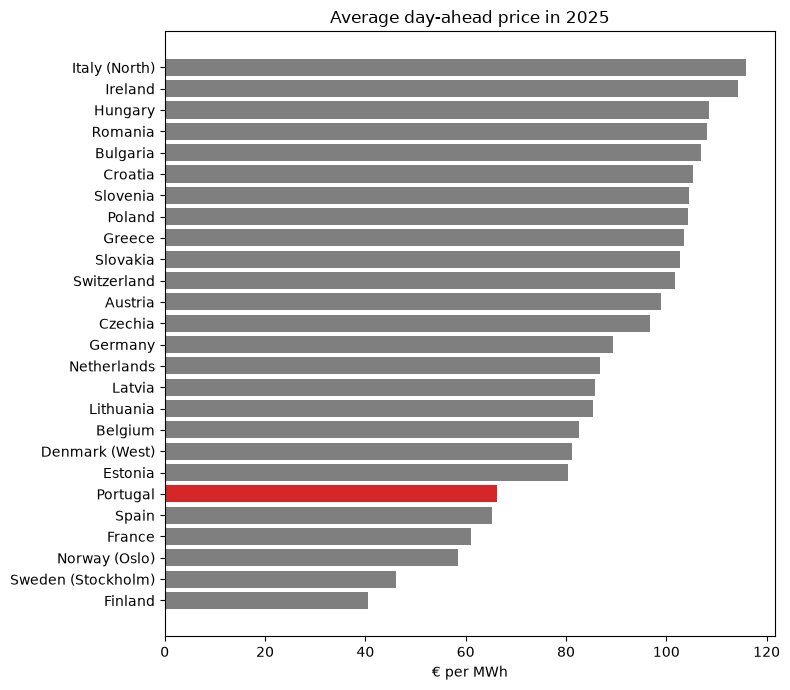

In [20]:
# 1. Average price in 2025 in each zone
query = """
SELECT zone, ROUND(AVG(price), 1) AS average_price
FROM europe_prices
WHERE substr(time, 1, 4) = '2025'
GROUP BY zone
ORDER BY average_price DESC
"""
ranking = pd.read_sql(query, con).set_index("zone")
ranking_chart(ranking["average_price"], "Average day-ahead price in 2025", "€ per MWh", "europe_price_ranking.png")

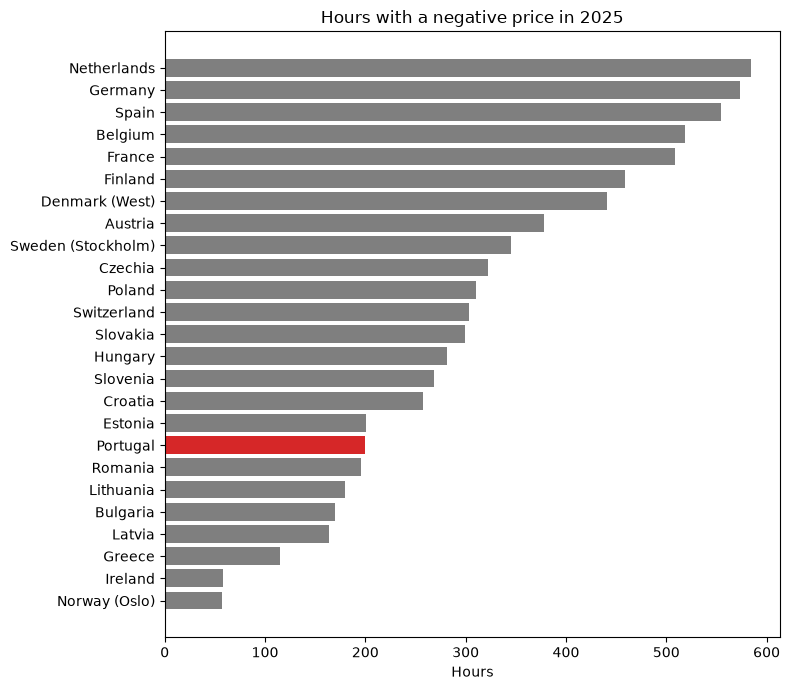

year,2019,2020,2021,2022,2023,2024,2025,2026
zone,,,,,,,,
AT,68.0,111.0,64.0,0.0,111.0,296.0,378.0,251.0
BE,71.0,136.0,159.0,112.0,222.0,404.0,519.0,293.0
BG,0.0,0.0,0.0,0.0,11.0,55.0,170.0,162.0
CH,17.0,75.0,41.0,1.0,76.0,292.0,303.0,239.0
CZ,58.0,119.0,33.0,8.0,134.0,315.0,322.0,271.0
DE_LU,211.0,298.0,139.0,68.0,301.0,457.0,573.0,461.0
DK_1,132.0,192.0,87.0,38.0,281.0,375.0,441.0,193.0
EE,0.0,5.0,5.0,2.0,129.0,183.0,201.0,46.0
ES,0.0,0.0,0.0,0.0,0.0,247.0,555.0,703.0


In [21]:
# 2. Hours with a negative price in each zone and year
query = """
SELECT zone, substr(time, 1, 4) AS year, COUNT(*) AS negative_hours
FROM europe_prices
WHERE price < 0
GROUP BY zone, year
"""
negative = pd.read_sql(query, con).pivot(index="zone", columns="year", values="negative_hours").fillna(0)
ranking_chart(negative["2025"], "Hours with a negative price in 2025", "Hours", "europe_negative_hours.png")
negative

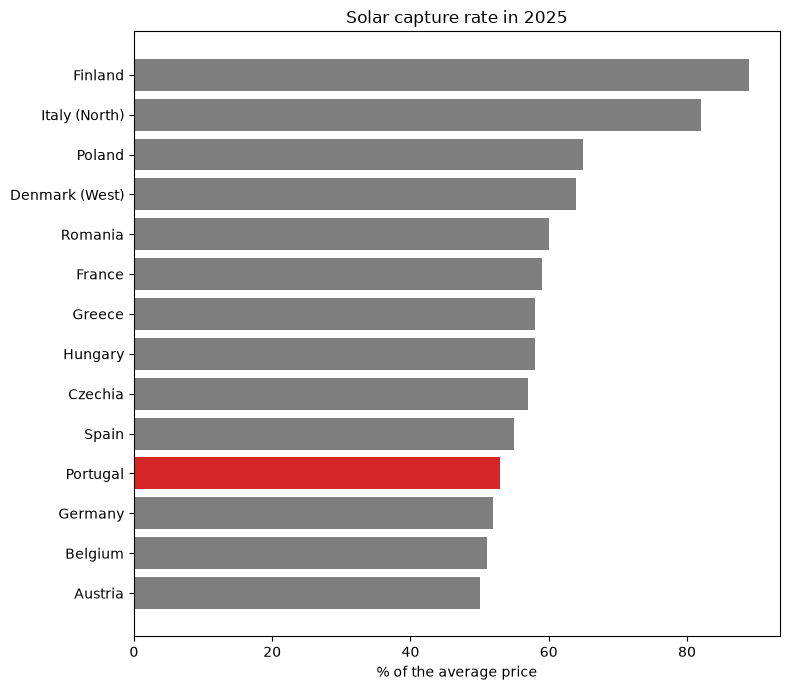

,PT,ES,FR,DE_LU,IT_NORD,BE,PL,AT,DK_1,FI,GR,HU,RO,CZ
time,,,,,,,,,,,,,,
2019,102.0,102.0,96.0,93.0,99.0,92.0,NaN,95.0,96.0,NaN,98.0,113.0,104.0,98.0
2020,98.0,97.0,93.0,80.0,88.0,77.0,106.0,88.0,97.0,NaN,92.0,89.0,92.0,86.0
2021,96.0,91.0,86.0,78.0,85.0,74.0,94.0,82.0,87.0,NaN,91.0,91.0,95.0,85.0
2022,90.0,90.0,106.0,94.0,103.0,92.0,91.0,106.0,101.0,NaN,94.0,102.0,99.0,96.0
2023,83.0,84.0,86.0,76.0,85.0,78.0,90.0,75.0,79.0,90.0,79.0,81.0,80.0,80.0
2024,67.0,67.0,68.0,59.0,89.0,56.0,75.0,63.0,67.0,85.0,71.0,63.0,66.0,63.0
2025,53.0,55.0,59.0,52.0,82.0,51.0,65.0,50.0,64.0,89.0,58.0,58.0,60.0,57.0
2026,51.0,52.0,55.0,53.0,85.0,56.0,60.0,52.0,68.0,73.0,41.0,57.0,62.0,57.0


In [22]:
# Zones with good solar data (the Netherlands is left out because ENTSO-E only has part of its solar)
solar_zones = ["PT", "ES", "FR", "DE_LU", "IT_NORD", "BE", "PL", "AT", "DK_1", "FI", "GR", "HU", "RO", "CZ"]

# 3. Solar capture rate: average price received by solar divided by the average price, in %
capture = {}
for zone in solar_zones:
    data = pd.DataFrame({"price": prices[zone], "solar": production[zone + "_solar"]}).dropna()
    data["value"] = data["price"] * data["solar"]
    yearly = data.groupby(data.index.year).sum()
    average_price = data.groupby(data.index.year)["price"].mean()
    capture[zone] = yearly["value"] / yearly["solar"] / average_price * 100
capture = pd.DataFrame(capture).round(0)
ranking_chart(capture.loc[2025], "Solar capture rate in 2025", "% of the average price", "europe_capture_rate.png")
capture

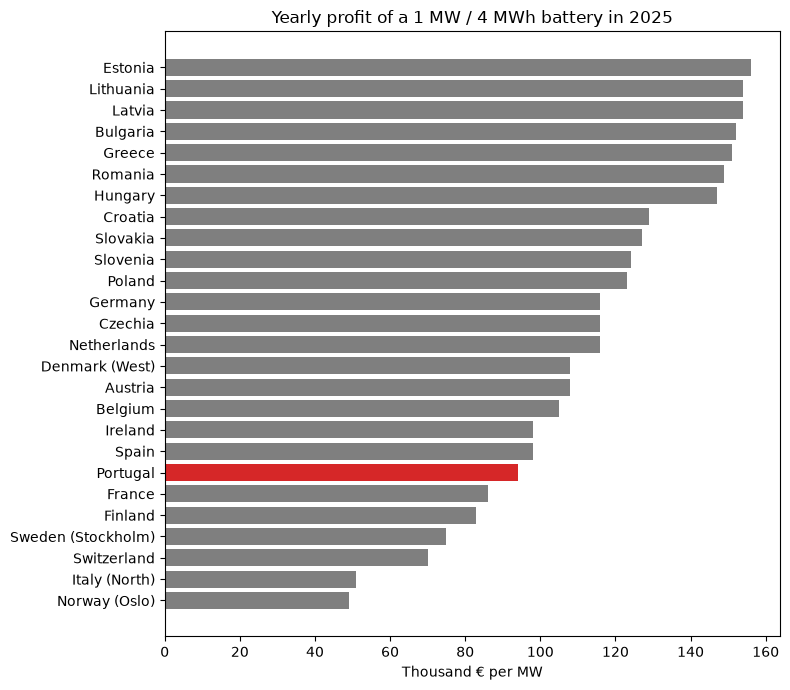

,PT,ES,FR,BE,NL,DE_LU,AT,CH,IT_NORD,PL,...,BG,GR,DK_1,SE_3,NO_1,FI,EE,LV,LT,IE_SEM
time,,,,,,,,,,,,,,,,,,,,,
2019,9.0,9.0,22.0,24.0,20.0,25.0,21.0,14.0,21.0,53.0,...,76.0,16.0,20.0,9.0,0.0,23.0,27.0,28.0,28.0,47.0
2020,11.0,12.0,22.0,26.0,27.0,29.0,23.0,17.0,21.0,15.0,...,55.0,29.0,28.0,27.0,2.0,39.0,46.0,45.0,45.0,45.0
2021,32.0,33.0,59.0,69.0,70.0,70.0,59.0,41.0,39.0,38.0,...,146.0,61.0,64.0,66.0,22.0,77.0,84.0,82.0,83.0,98.0
2022,67.0,69.0,131.0,166.0,177.0,162.0,127.0,84.0,112.0,121.0,...,217.0,171.0,153.0,189.0,54.0,201.0,225.0,206.0,204.0,129.0
2023,60.0,65.0,72.0,79.0,97.0,87.0,75.0,48.0,56.0,56.0,...,112.0,101.0,83.0,60.0,30.0,71.0,115.0,111.0,111.0,74.0
2024,64.0,67.0,72.0,86.0,105.0,102.0,87.0,53.0,49.0,105.0,...,160.0,138.0,91.0,48.0,32.0,77.0,143.0,138.0,138.0,88.0
2025,94.0,98.0,86.0,105.0,116.0,116.0,108.0,70.0,51.0,123.0,...,152.0,151.0,108.0,75.0,49.0,83.0,156.0,154.0,154.0,98.0
2026,131.0,137.0,136.0,145.0,156.0,159.0,148.0,106.0,71.0,169.0,...,161.0,176.0,140.0,81.0,54.0,69.0,125.0,140.0,140.0,97.0


In [23]:
# Profit of a 1 MW battery in one day: buy in the 4 cheapest hours, sell in the 4 most expensive, losing 15%
def battery_profit(day_prices):
    sorted_prices = day_prices.sort_values()
    return sorted_prices.tail(4).sum() * 0.85 - sorted_prices.head(4).sum()

# 4. Yearly profit of the battery in each zone, in thousand € per MW
battery = {}
for zone in prices.columns:
    zone_prices = prices[zone].dropna()
    daily = zone_prices.groupby(zone_prices.index.strftime("%Y-%m-%d")).apply(battery_profit)
    battery[zone] = daily.groupby(daily.index.str[:4]).mean() * 365 / 1000
battery = pd.DataFrame(battery).round(0)
ranking_chart(battery.loc["2025"], "Yearly profit of a 1 MW / 4 MWh battery in 2025", "Thousand € per MW", "europe_battery_value.png")
battery

In [24]:
# Summary table for 2025
summary = pd.DataFrame({
    "average_price": ranking["average_price"],
    "negative_hours": negative["2025"],
    "solar_capture_rate": capture.loc[2025],
    "battery_profit": battery.loc["2025"],
})
summary["negative_hours"] = summary["negative_hours"].fillna(0)
summary = summary.sort_values("average_price", ascending=False).rename(index=names)
summary.to_csv("../data/europe_summary_2025.csv")
summary

,average_price,negative_hours,solar_capture_rate,battery_profit
Italy (North),115.9,0.0,82.0,51.0
Ireland,114.3,58.0,NaN,98.0
Hungary,108.5,281.0,58.0,147.0
Romania,108.2,196.0,60.0,149.0
Bulgaria,106.9,170.0,NaN,152.0
Croatia,105.4,257.0,NaN,129.0
Slovenia,104.6,268.0,NaN,124.0
Poland,104.3,310.0,65.0,123.0
Greece,103.6,115.0,58.0,151.0
Slovakia,102.7,299.0,NaN,127.0
